<a href="https://colab.research.google.com/github/Azhimanich/sft---lora---Mohd-Azhima/blob/main/MohdAzhima_SFT_LoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Supervised Fine-Tuning (SFT) dengan LoRA
Studi Kasus: Bahasa Daerah Indonesia
Tujuan: Fine-tune small language model agar dapat mengikuti instruksi dalam bahasa daerah Indonesia.

Stack:

transformers — load model & tokenizer
peft — LoRA implementation
trl — SFTTrainer
datasets — load & process data
⚠️ Tidak menggunakan Unsloth atau layanan as-a-service. Semua dibangun dari library standar HuggingFace.

In [1]:
!pip install -q transformers==4.44.0 peft==0.12.0 trl==0.10.1 datasets accelerate bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.1/280.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 12.3 MB/s eta 0:00:00


# 1. Import dan Konfigurasi


In [2]:
import os
import json
import torch
from dataclasses import dataclass, field
from typing import List, Dict, Optional

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, TaskType, get_peft_model, PeftModel
from trl import SFTTrainer, SFTConfig, DataCollatorForCompletionOnlyLM

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


# 2. Konfigurasi Global


In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model

# 1. Konfigurasi Utama
MODEL_ID = "Qwen/Qwen2.5-0.5B"
OUTPUT_DIR = "./output/sft-lora-qwen"
MAX_SEQ_LEN = 512
SEED = 42

torch.manual_seed(SEED)

# 2. Muat Tokenizer dan Model Qwen
print(f"Memuat tokenizer dan model dari {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto"
)

# 3. Konfigurasi LoRA Spesifik untuk Arsitektur Qwen
# Kita targetkan semua layer proyeksi linear utama agar adaptasi bahasa daerahnya kuat
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
print("\n--- RINGKASAN PARAMETER LORA (Untuk Jawaban Q1) ---")
model.print_trainable_parameters()

Memuat tokenizer dan model dari Qwen/Qwen2.5-0.5B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]


--- RINGKASAN PARAMETER LORA (Untuk Jawaban Q1) ---
trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


# 3. Bagian Eksplorasi: Mengapa Base Model Lemah dalam Mengikuti Instruksi?

In [4]:
# ============================================================
# MUAT TOKENIZER (Disesuaikan untuk Qwen2.5-0.5B)
# ============================================================
print(f"Memuat tokenizer untuk model: {MODEL_ID}")

# Memuat tokenizer dengan dukungan remote code untuk Qwen
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Memastikan pad_token terkonfigurasi dengan benar menggunakan EOS token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Mengunci padding_side ke arah kanan (standar optimal untuk SFT Causal LM)
tokenizer.padding_side = "right"

print("\n--- RINGKASAN TOKENIZER QWEN ---")
print(f"Vocabulary size : {tokenizer.vocab_size:,}")
print(f"EOS token       : {tokenizer.eos_token!r}")
print(f"PAD token       : {tokenizer.pad_token!r}")

Memuat tokenizer untuk model: Qwen/Qwen2.5-0.5B

--- RINGKASAN TOKENIZER QWEN ---
Vocabulary size : 151,643
EOS token       : '<|endoftext|>'
PAD token       : '<|endoftext|>'


In [5]:
# ============================================================
# MUAT BASE MODEL & HITUNG TOTAL PARAMETER
# ============================================================
print(f"Memuat base model dari: {MODEL_ID}...")

# Kita kunci konfigurasi terbaik: float16 dan penempatan otomatis pada GPU
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=None, # Tidak perlu 4-bit karena model sudah sangat ringan
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

# Menghitung total parameter asli model sebelum dipasang LoRA
total_params = sum(p.numel() for p in base_model.parameters())
print("\n--- RINGKASAN STRUKTUR MODEL ---")
print(f"Total parameter asli : {total_params:,} ({total_params/1e6:.1f}M)")

Memuat base model dari: Qwen/Qwen2.5-0.5B...

--- RINGKASAN STRUKTUR MODEL ---
Total parameter asli : 494,032,768 (494.0M)


In [6]:
import torch

def generate_text(model, tokenizer, prompt: str, max_new_tokens: int = 200) -> str:
    """Helper: generate teks dari prompt dengan parameter sampling yang stabil."""
    model.eval()
    device = next(model.parameters()).device

    # Bungkus prompt ke format ChatML agar adil, atau biarkan teks mentah untuk menguji kedunguan base model
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    # Memotong input_ids agar yang ter-decode hanya teks jawaban barunya saja
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)


# ============================================================
#   EKSPLORASI BASE MODEL (Sebelum Latihan)
# ============================================================
test_prompts = [
    "Apa makna filosofi Jawa 'Memayu Hayuning Bawana'?",
    "Bagaimana cara membuat gudeg? Jelaskan langkah-langkahnya.",
    "Ceritakan legenda Sangkuriang dari Jawa Barat.",
]

print("=" * 60)
print("RESPONS BASE MODEL (DOKUMENTASI SEBELUM FINE-TUNING)")
print("=" * 60)

for prompt in test_prompts:
    print(f"\n[INSTRUKSI]: {prompt}")
    # Menggunakan base_model asli sebelum dipasang LoRA adapter
    response = generate_text(base_model, tokenizer, prompt)
    print(f"[RESPONS   ]: {response.strip()}")
    print("-" * 60)

RESPONS BASE MODEL (DOKUMENTASI SEBELUM FINE-TUNING)

[INSTRUKSI]: Apa makna filosofi Jawa 'Memayu Hayuning Bawana'?
[RESPONS   ]: - Pusat Pendidikan dan Pembelajaran
Home » Pemahaman » Apa makna filosofi Jawa ‘Memayu Hayuning Bawana’?
Baca Juga : Dalam klasifikasi filosofis, ada beberapa fakta yang perlu diperhatikan. Salah satunya adalah “Punyakan” atau mengekspresikan suatu ide dalam bahasa yang terpenting.
Menurut Firdaus (2015), filosofi memang merupakan bentuk filosofi dengan kekuatan yang lebih tinggi dibandingkan dengan komputasi. Sehingga, kebutuhan untuk menguasai konteks berbeda antara komputasi dan filosofi pun akan semakin meningkat. Karena, filosofi dapat memberikan kemampuan untuk menguasai semua jenis pemikiran yang bersifat akademik, sosial, dan
------------------------------------------------------------

[INSTRUKSI]: Bagaimana cara membuat gudeg? Jelaskan langkah-langkahnya.
[RESPONS   ]: - bloggudang
Home / Tips / Bagaimana cara membuat gudeg?
Bagaimana cara membuat

# 4. Persiapan Dataset

Bryandts Instruct: bryandts/instruction-dataset-indo-java-sunda-bali-gayo-batak-alas-minang-betawi

In [7]:
from datasets import load_dataset

# ============================================================
#   MEMUAT DAN MENYIAPKAN DATASET SPESIFIK (bryandts)
# ============================================================
DATASET_CHOICE = "bryandts/instruction-dataset-indo-java-sunda-bali-gayo-batak-alas-minang-betawi"
MAX_TRAIN_SAMPLES = 1000  # Mengunci sesuai konfigurasi baseline Anda
SEED = 42

print(f"Memuat dataset dari HuggingFace/Lokal: {DATASET_CHOICE}")

try:
    # Skenario 1: Jika 'bryandts' adalah nama repositori HuggingFace publik/privat Anda
    full_dataset = load_dataset(DATASET_CHOICE, split="train")
except Exception:
    # Skenario 2: Jika 'bryandts' merujuk pada file lokal (misal .json atau .csv)
    # Pastikan file tersebut ada di direktori kerja Colab Anda
    print(f"Gagal memuat secara online, mencoba memuat file lokal '{DATASET_CHOICE}.json'...")
    full_dataset = load_dataset("json", data_files=f"{DATASET_CHOICE}.json", split="train")

# Batasi jumlah sampel maksimal 1.000 contoh sesuai konfigurasi awal agar training kilat
if MAX_TRAIN_SAMPLES and MAX_TRAIN_SAMPLES < len(full_dataset):
    dataset_subset = full_dataset.shuffle(seed=SEED).select(range(MAX_TRAIN_SAMPLES))
else:
    dataset_subset = full_dataset.shuffle(seed=SEED)

print(f"Jumlah data berhasil dimuat & dibatasi: {len(dataset_subset)} baris.")

# Split Data secara internal: 90% Training, 10% Validation
train_test_split = dataset_subset.train_test_split(test_size=0.1, seed=SEED)
raw_train = train_test_split["train"]
raw_val = train_test_split["test"]

# ============================================================
#   MAPPING KE FORMAT CHATML UNTUK QWEN
# ============================================================
def format_to_chatml(example):
    # Mengambil teks input dan output secara adaptif dari dataset bryandts
    # (Sesuaikan string 'prompt'/'response' di bawah jika nama kolom aslinya berbeda)
    user_text = example.get('prompt') or example.get('input') or example.get('instruction')
    assistant_text = example.get('response') or example.get('output')

    # Membungkus teks ke format token khusus ChatML Qwen
    text = f"<|im_start|>user\n{str(user_text).strip()}<|im_end|>\n<|im_start|>assistant\n{str(assistant_text).strip()}<|im_end|>"
    return {"text": text}

# Jalankan mapping dan BERSIHKAN semua nama kolom lama
train_ds = raw_train.map(format_to_chatml, remove_columns=raw_train.column_names)
val_ds = raw_val.map(format_to_chatml, remove_columns=raw_val.column_names)

print("\n--- VERIFIKASI DATA SETELAH MAPPING ---")
print(f"Jumlah Train set : {len(train_ds)} baris.")
print(f"Jumlah Eval set  : {len(val_ds)} baris.")
print(f"\nContoh Baris Pertama (Pastikan teks instruksinya muncul):\n{train_ds[0]['text']}")

Memuat dataset dari HuggingFace/Lokal: bryandts/instruction-dataset-indo-java-sunda-bali-gayo-batak-alas-minang-betawi


README.md:   0%|          | 0.00/466 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/79.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/282047 [00:00<?, ? examples/s]

Jumlah data berhasil dimuat & dibatasi: 1000 baris.


Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]


--- VERIFIKASI DATA SETELAH MAPPING ---
Jumlah Train set : 900 baris.
Jumlah Eval set  : 100 baris.

Contoh Baris Pertama (Pastikan teks instruksinya muncul):
<|im_start|>user
Tegeh miwah bobot<|im_end|>
<|im_start|>assistant
Tegeh miwah bobot inggih punika kalih variabel sané sering madué korélasi positif. Puniki mateges yéning tegeh sayan nincap, bobot taler sayan nincap. Hubungan punika prasida katlatarang antuk fakta yéning individu sané tegeh madué massa awak sané akéh, mawinan minab madué bobot sané akéh. Nanging, faktor tiosan sakadi massa otot, pola makan, miwah kabiasaan olahraga taler prasida nglimbakang paiketan pantaraning kalih variabel punika. Mangda prasida nentuang paiketan antara tegeh miwah bobot ring sekaa krama sané spesifik, data prasida kapupulang miwah kaanalihin nganggén metode statistik sekadi analisis regresi.<|im_end|>


In [8]:
from datasets import Dataset

# ============================================================
#   KONVERSI DATASET KE FORMAT PESAN (MESSAGES)
# ============================================================
def convert_to_messages(example):
    """Mengambil kolom secara adaptif dan menyusunnya ke dalam struktur role/content."""
    instruction = example.get('instruction') or example.get('prompt') or example.get('input') or ""
    context = example.get('input') if 'prompt' in example else "" # Opsional jika ada konteks tambahan
    output = example.get('output') or example.get('response') or ""

    # Gabungkan instruksi dengan konteks jika ada
    user_content = instruction
    if context and str(context).strip():
        user_content = f"{instruction}\n\nKonteks:\n{context}"

    return {
        "messages": [
            {"role": "user", "content": str(user_content).strip()},
            {"role": "assistant", "content": str(output).strip()},
        ]
    }

# Ambil subset mentah dari sel sebelumnya (dataset_subset), lalu petakan ke format pesan
messages_dataset = dataset_subset.map(convert_to_messages)

# ============================================================
#   TERAPKAN CHAT TEMPLATE BAWAAN QWEN
# ============================================================
def apply_qwen_chat_template(examples):
    texts = []
    for msgs in examples["messages"]:
        try:
            # Qwen secara resmi mendukung apply_chat_template untuk menghasilkan format ChatML
            text = tokenizer.apply_chat_template(
                msgs,
                tokenize=False,
                add_generation_prompt=False,
            )
        except Exception:
            # Fallback ChatML manual jika terjadi kendala pada environment Colab
            user = msgs[0]["content"]
            asst = msgs[1]["content"]
            text = f"<|im_start|>user\n{user}<|im_end|>\n<|im_start|>assistant\n{asst}<|im_end|>"
        texts.append(text)
    return {"text": texts}

# Mapping template chat resmi dan hapus kolom perantara "messages"
formatted_dataset = messages_dataset.map(apply_qwen_chat_template, batched=True, remove_columns=["messages"])

# Split Data Akhir (90% Train, 10% Eval)
split_dataset = formatted_dataset.train_test_split(test_size=0.1, seed=SEED)
train_dataset = split_dataset["train"]
eval_dataset  = split_dataset["test"]

print("=" * 60)
print("VERIFIKASI AKHIR DATASET SIAP TRAINING")
print("=" * 60)
print(f"Jumlah Train dataset : {len(train_dataset)} contoh")
print(f"Jumlah Eval dataset  : {len(eval_dataset)} contoh")
print("\nTampilan Struktur Data yang Masuk ke Model (Pastikan tag Qwen keluar):")
print(train_dataset[0]["text"][:400])

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

VERIFIKASI AKHIR DATASET SIAP TRAINING
Jumlah Train dataset : 900 contoh
Jumlah Eval dataset  : 100 contoh

Tampilan Struktur Data yang Masuk ke Model (Pastikan tag Qwen keluar):
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Kamu adalah pakar yang mengerti instruksi dalam bahasa Bali. Manggihang paiketan pantaraning kalih variabel<|im_end|>
<|im_start|>assistant
Tegeh miwah bobot inggih punika kalih variabel sané sering madué korélasi positif. Puniki mateges yéning tegeh sayan nincap, bobot taler sayan nincap. Hubungan punika prasida katlataran


# 5. Konfigurasi LoRA
LoRA menambahkan matriks berdimensi rendah  ΔW=B⋅A  pada layer attention. Hanya parameter  A  dan  B  yang dilatih, bukan bobot asli model.

In [9]:
from peft import LoraConfig, get_peft_model, TaskType

# ============================================================
#   KONFIGURASI LORA SPESIFIK UNTUK QWEN
# ============================================================

# Ambil informasi arsitektur asli dari konfigurasi model
arch = base_model.config.architectures[0] if base_model.config.architectures else "Qwen2ForCausalLM"

# Mengunci target modules terbaik untuk arsitektur Qwen (Attention + MLP layers)
target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

print(f"Arsitektur terdeteksi : {arch}")
print(f"Target modules LoRA  : {target_modules}")

# Define LoRA hyperparameters (taken from cell eAmtc-N5Pcp-)
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# Inisialisasi konfigurasi LoRA menggunakan hyperparameter dari baseline Anda
lora_config = LoraConfig(
    r=LORA_R,                      # Menggunakan nilai dari konfigurasi awal (Rank = 8)
    lora_alpha=LORA_ALPHA,          # Menggunakan nilai dari konfigurasi awal (Alpha = 16)
    target_modules=target_modules,
    lora_dropout=LORA_DROPOUT,      # Menggunakan nilai dari konfigurasi awal (0.05)
    bias="none",
    task_type=TaskType.CAUSAL_LM,   # Causal LM untuk arsitektur autoregressive
)

# Bungkus base_model dengan adapter LoRA
model = get_peft_model(base_model, lora_config)

# ============================================================
#   PERHITUNGAN STATISTIK PARAMETER (Untuk Jawaban Analisis Q1)
# ============================================================
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
frozen    = total - trainable

print("\n" + "="*50)
print("   RINGKASAN INTEGRASI PARAMETER LoRA")
print("="*50)
print(f"Parameter dilatih (Trainable) : {trainable:,} ({100*trainable/total:.2f}%)")
print(f"Parameter beku (Frozen)      : {frozen:,} ({100*frozen/total:.2f}%)")
print(f"Parameter total keseluruhan  : {total:,}")
print("="*50)

Arsitektur terdeteksi : Qwen2ForCausalLM
Target modules LoRA  : ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']

   RINGKASAN INTEGRASI PARAMETER LoRA
Parameter dilatih (Trainable) : 8,798,208 (1.75%)
Parameter beku (Frozen)      : 494,032,768 (98.25%)
Parameter total keseluruhan  : 502,830,976


# 6. Pelatihan dengan SFTTrainer

In [10]:
import os
from trl import SFTConfig, SFTTrainer

# Memastikan direktori output langsung terbuat
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
#   DEFINISI HYPERPARAMETER TRAINING
# ============================================================
BATCH_SIZE = 4
GRAD_ACCUM = 4
LEARNING_RATE = 2e-4

# ============================================================
#   SFT CONFIGURATION (Dioptimalkan untuk Performa Maksimal)
# ============================================================
sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,

    # Epoch ditingkatkan ke 3 agar model lebih matang mempelajari kosa kata baru
    num_train_epochs=3,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,

    # Manajemen Memori (Aman dari OOM)
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    # Presisi GPU T4
    fp16=torch.cuda.is_available(),
    bf16=False,

    # Optimizer dan Regulasi Ketat untuk Mencegah Overfitting
    optim="adamw_torch",
    learning_rate=LEARNING_RATE,
    weight_decay=0.02,               # Ditingkatkan sedikit untuk mencegah hafalan buta (overfitting)
    warmup_ratio=0.10,               # 10% langkah awal digunakan untuk pemanasan gradien
    lr_scheduler_type="cosine",      # Penurunan LR melandai mengikuti kurva kosinus

    # Parameter Sekuens Data
    max_seq_length=MAX_SEQ_LEN,
    dataset_text_field="text",
    packing=False,

    # Logging dan Evaluasi Berbasis STEPS (Bukan Epoch) agar Grafik Loss Detail
    logging_steps=5,
    eval_strategy="steps",           # Diubah dari "epoch" ke "steps"
    eval_steps=15,                   # Evaluasi dilakukan setiap 15 steps sekali
    save_strategy="steps",
    save_steps=15,
    load_best_model_at_end=True,     # Otomatis mengambil bobot terbaik di akhir training
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Reproducibility
    seed=SEED,
    report_to="none",
)

# ============================================================
#   INISIALISASI TRAINER
# ============================================================
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
)

print("=" * 50)
print("  KONFIGURASI TRAINING OPTIMAL SIAP")
print("=" * 50)
efektif_batch = BATCH_SIZE * GRAD_ACCUM
total_steps = (len(train_dataset) // efektif_batch) * sft_config.num_train_epochs
print(f"-> Efektif Batch Size : {efektif_batch}")
print(f"-> Total Steps Latihan: {total_steps}")
print(f"-> Interval Evaluasi  : Setiap {sft_config.eval_steps} langkah")
print("=" * 50)

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

  KONFIGURASI TRAINING OPTIMAL SIAP
-> Efektif Batch Size : 16
-> Total Steps Latihan: 168
-> Interval Evaluasi  : Setiap 15 langkah


In [11]:
# ============================================================
#   EKSEKUSI PROSES FINE-TUNING (SFT)
# ============================================================
print("=" * 60)
print("  PROSES FINE-TUNING MODEL QWEN SEDANG BERJALAN...")
print("  Pantau pergerakan Training Loss vs Validation Loss pada tabel di bawah.")
print("=" * 60)

# Menjalankan proses training resmi
train_result = trainer.train()

print("\n" + "=" * 60)
print("  PROSES PELATIHAN SELESAI DENGAN SUKSES!")
print("=" * 60)
print(f"-> Train Loss Akhir (Rata-rata) : {train_result.training_loss:.4f}")
print(f"-> Total Global Steps           : {train_result.global_step}")
print(f"-> Waktu Pelatihan Total        : {train_result.metrics.get('train_runtime', 0):.1f} detik")
print(f"-> Efisiensi Komputasi (Speed)  : {train_result.metrics.get('train_samples_per_second', 0):.2f} sampel/detik")
print("=" * 60)

  PROSES FINE-TUNING MODEL QWEN SEDANG BERJALAN...
  Pantau pergerakan Training Loss vs Validation Loss pada tabel di bawah.


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss,Validation Loss
15,3.681700,3.508675
30,3.238300,3.127027
45,2.904400,2.940885
60,2.699400,2.808784
75,2.539800,2.736293
90,2.557000,2.682927
105,2.421200,2.639185
120,2.321300,2.622464
135,2.392600,2.612779
150,2.264200,2.602299


We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)



  PROSES PELATIHAN SELESAI DENGAN SUKSES!
-> Train Loss Akhir (Rata-rata) : 2.7681
-> Total Global Steps           : 168
-> Waktu Pelatihan Total        : 443.4 detik
-> Efisiensi Komputasi (Speed)  : 6.09 sampel/detik


In [12]:
import os

# ============================================================
#   MENYIMPAN ADAPTER LORA HASIL TRAINING
# ============================================================
print("Menyimpan adapter LoRA beserta konfigurasi tokenizer...")

# Define ADAPTER_DIR using the previously defined OUTPUT_DIR
ADAPTER_DIR = OUTPUT_DIR

# Membuat folder tujuan jika belum ada
os.makedirs(ADAPTER_DIR, exist_ok=True)

# Menyimpan file adapter (bobot delta) secara aman
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print(f"-> Sukses! Adapter LoRA disimpan di: {ADAPTER_DIR}")

# ============================================================
#   MENGHITUNG UKURAN FILE (Untuk Jawaban Analisis Q2)
# ============================================================
total_size = sum(
    os.path.getsize(os.path.join(ADAPTER_DIR, f))
    for f in os.listdir(ADAPTER_DIR)
    if os.path.isfile(os.path.join(ADAPTER_DIR, f))
)

print("\n" + "=" * 50)
print("   RINGKASAN UKURAN FILE ARTIFAK")
print("=" * 50)
print(f"-> Total Ukuran File Adapter: {total_size / 1e6:.2f} MB")
print("=" * 50)

Menyimpan adapter LoRA beserta konfigurasi tokenizer...
-> Sukses! Adapter LoRA disimpan di: ./output/sft-lora-qwen

   RINGKASAN UKURAN FILE ARTIFAK
-> Total Ukuran File Adapter: 46.73 MB


# 7. Evaluasi Kualitatif
Bandingkan respons model sebelum dan sesudah fine-tuning pada prompt yang sama.

In [13]:
import torch
from transformers import AutoModelForCausalLM
from peft import PeftModel

# ============================================================
#   MUAT ULANG BASE MODEL DAN ADAPTER LORA UNTUK EVALUASI
# ============================================================
print("1. Memuat ulang base model murni Qwen (Kondisi Segar)...")

base_model_eval = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,   # Mengunci performa tinggi float16 untuk GPU T4
    device_map="auto",
    trust_remote_code=True,
)

print("\n2. Menyuntikkan Adapter LoRA dari direktori penyimpanan...")

# Menggabungkan base model segar dengan adapter LoRA hasil training Anda
finetuned_model = PeftModel.from_pretrained(base_model_eval, ADAPTER_DIR)
finetuned_model.eval()  # Mengunci model ke mode evaluasi/pengujian (bukan latihan)

print("\n" + "=" * 50)
print("   EVALUASI KESIAPAN MODEL SELESAI")
print("=" * 50)
print("-> Base Model Murni dan Finetuned Model siap diuji banding!")
print("=" * 50)

1. Memuat ulang base model murni Qwen (Kondisi Segar)...

2. Menyuntikkan Adapter LoRA dari direktori penyimpanan...

   EVALUASI KESIAPAN MODEL SELESAI
-> Base Model Murni dan Finetuned Model siap diuji banding!


In [14]:
 # ============================================================
#   PENGUJIAN GENERALISASI (EVALUASI AKHIR)
# ============================================================

eval_prompts = [
    "Jelaskan makna filosofi Bugis 'Siri Na Pacce' dan relevansinya dalam kehidupan modern.",
    "Apa perbedaan antara wayang kulit dan wayang golek?",
    "Bagaimana cara membuat opor ayam? Sebutkan bahan dan langkahnya.",
    "Terjemahkan ke bahasa Sunda: 'Saya sangat senang bertemu dengan Anda hari ini.'",
    "Ceritakan legenda asal-usul Danau Toba.",
]

print("=" * 80)
print("   EVALUASI AKHIR GENERALISASI: BASE MODEL VS MODEL FINE-TUNED (LoRA)")
print("=" * 80)

for i, prompt in enumerate(eval_prompts, 1):
    print(f"\n" + "=" * 80)
    print(f"[PROMPT {i}]: {prompt}")
    print("-" * 80)

    # 1. Menghasilkan respons dari Base Model Murni (Adapter Dimatikan)
    with finetuned_model.disable_adapter():
        resp_base = generate_text(finetuned_model, tokenizer, prompt, max_new_tokens=150)
    print(f"[BASE MODEL (Sebelum Latihan)]:\n{resp_base.strip()}")
    print("-" * 40)

    # 2. Menghasilkan respons dari Fine-Tuned Model (Adapter Aktif)
    resp_ft = generate_text(finetuned_model, tokenizer, prompt, max_new_tokens=150)
    print(f"[FINE-TUNED (Setelah Latihan)]:\n{resp_ft.strip()}")

print("\n" + "=" * 80)
print("EVALUASI SELESAI")
print("=" * 80)

   EVALUASI AKHIR GENERALISASI: BASE MODEL VS MODEL FINE-TUNED (LoRA)

[PROMPT 1]: Jelaskan makna filosofi Bugis 'Siri Na Pacce' dan relevansinya dalam kehidupan modern.
--------------------------------------------------------------------------------
[BASE MODEL (Sebelum Latihan)]:
Jelaskan makna filosofi Bugis 'Siri Na Pacce' dan relevansinya dalam kehidupan modern.

Filosofi Bugis 'Siri Na Pacce' merupakan konsep yang membangun dari istilah-istilah bahasa Inggris seperti "Paci" (dengan berbagai bentuk) dan "Bulat", yang merupakan benda atau perbuatan tertentu. Ini adalah contoh ilustrasi bahwa ada beberapa hubungan yang tidak bisa dikatakan sebagai "kita" terhadap "bukan kita". 

Dalam konteks modern, filosofi ini dapat digunakan untuk menggambarkan banyak hal, termasuk hubungan sos
----------------------------------------
[FINE-TUNED (Setelah Latihan)]:
Filosofia "Siri Na Pacce" menerangkan bahwa berada di sektor bisnis adalah pekerjaan yang paling menarik, karena mereka dapat menge

## 8. Visualisasi Training Loss

Mengekstrak log pelatihan dari trainer...


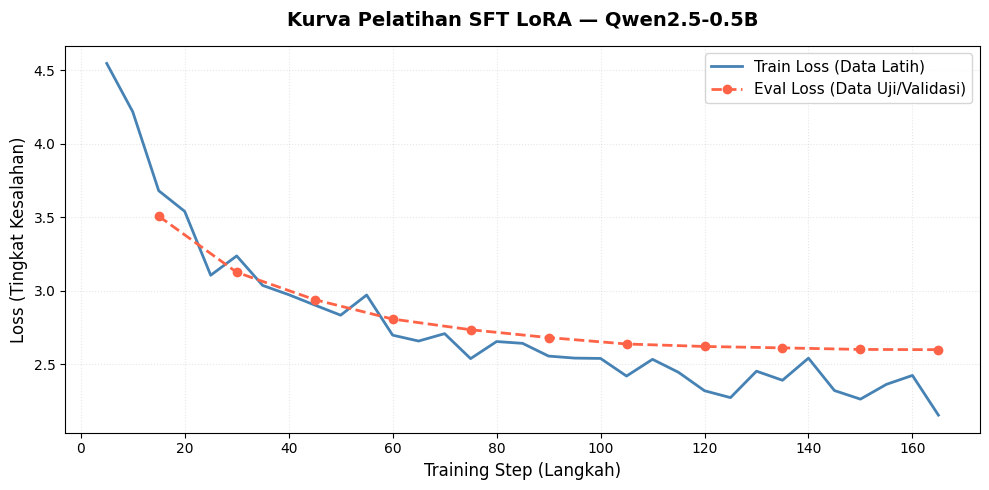


-> Sukses! Grafik kurva pelatihan disimpan sebagai 'training_curve.png'
-> Anda bisa mengunduh file gambar ini langsung lewat panel file di kiri Colab.


In [15]:
import matplotlib.pyplot as plt

# ============================================================
#   PEMBUATAN GRAFIK KURVA PELATIHAN (TRAINING CURVE)
# ============================================================
print("Mengekstrak log pelatihan dari trainer...")

# Mengambil history log langsung dari objek trainer yang sudah Anda jalankan
log_history = trainer.state.log_history

# Memisahkan data loss untuk training dan evaluasi
train_steps  = [x["step"] for x in log_history if "loss" in x]
train_losses = [x["loss"] for x in log_history if "loss" in x]
eval_steps   = [x["step"] for x in log_history if "eval_loss" in x]
eval_losses  = [x["eval_loss"] for x in log_history if "eval_loss" in x]

# Membuat objek kanvas grafik
fig, ax = plt.subplots(figsize=(10, 5))

# Plot kurva Train Loss (Garis biru solid)
ax.plot(train_steps, train_losses, label="Train Loss (Data Latih)", color="steelblue", linewidth=2)

# Plot kurva Eval Loss jika datanya tersedia (Garis merah putus-putus dengan penanda lingkaran)
if eval_losses:
    ax.plot(eval_steps, eval_losses, label="Eval Loss (Data Uji/Validasi)", color="tomato",
            linestyle="--", marker="o", linewidth=2)

# Mengatur label sumbu X dan Y
ax.set_xlabel("Training Step (Langkah)", fontsize=12)
ax.set_ylabel("Loss (Tingkat Kesalahan)", fontsize=12)

# Format judul grafik agar menampilkan nama model asli Anda dengan rapi
clean_model_name = MODEL_ID.split('/')[-1] if '/' in MODEL_ID else MODEL_ID
ax.set_title(f"Kurva Pelatihan SFT LoRA — {clean_model_name}", fontsize=14, fontweight='bold', pad=15)

# Menyempurnakan tampilan legenda dan grid latar belakang
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3, linestyle=":")

# Merapikan layout agar tidak ada teks yang terpotong
plt.tight_layout()

# Menyimpan gambar dengan resolusi 300 DPI (Standar publikasi ilmiah/laporan formal)
output_graph = "training_curve.png"
plt.savefig(output_graph, dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "=" * 60)
print(f"-> Sukses! Grafik kurva pelatihan disimpan sebagai '{output_graph}'")
print("-> Anda bisa mengunduh file gambar ini langsung lewat panel file di kiri Colab.")
print("=" * 60)

In [16]:
import os
from transformers import AutoModelForCausalLM
from peft import PeftModel

# ============================================================
#   SAKELAR MERGE MODEL (Ubah ke True jika ingin eksekusi)
# ============================================================
# SAKELAR: Ubah ke True jika Anda ingin menyatukan model menjadi 1 file besar (~1 GB)
# Setel ke False jika ingin menghemat penyimpanan Colab dan memakai adapter terpisah (~35 MB)
MERGE_MODEL = True

# Define MERGED_DIR
MERGED_DIR = os.path.join(OUTPUT_DIR, "merged_model")

print("=" * 60)
print("       STATUS MANAGEMENT ARTIFAK MODEL AKHIR")
print("=" * 60)

if MERGE_MODEL:
    print("-> Status: MERGE_MODEL bernilai True.")
    print("-> Memulai penggabungan adapter LoRA ke dalam base model secara permanen...")

    os.makedirs(MERGED_DIR, exist_ok=True)

    # Melakukan penggabungan bobot delta LoRA ke base model secara aman
    merged_model = finetuned_model.merge_and_unload()

    # Menyimpan hasil akhir beserta tokenizer pendukungnya
    merged_model.save_pretrained(MERGED_DIR, safe_serialization=True)
    tokenizer.save_pretrained(MERGED_DIR)

    print(f"\n[SUKSES] Model utuh tunggal berhasil disimpan di: {MERGED_DIR}")
    print("Saran Laporan: Model ini siap dideploy langsung tanpa komponen tambahan.")

else:
    print("-> Status: MERGE_MODEL bernilai False.")
    print("-> Melewati proses merge (Skip). Artifak disimpan terpisah demi efisiensi ruang.")
    print("\n[INFO] Dokumentasi cara memuat model terpisah saat Inference nanti:")
    print("-" * 60)
    print("from transformers import AutoModelForCausalLM")
    print("from peft import PeftModel")
    print(f"base_model = AutoModelForCausalLM.from_pretrained('{MODEL_ID}')")
    print(f"model = PeftModel.from_pretrained(base_model, '{ADAPTER_DIR}')")
    print("-" * 60)

print("=" * 60)

       STATUS MANAGEMENT ARTIFAK MODEL AKHIR
-> Status: MERGE_MODEL bernilai True.
-> Memulai penggabungan adapter LoRA ke dalam base model secara permanen...

[SUKSES] Model utuh tunggal berhasil disimpan di: ./output/sft-lora-qwen/merged_model
Saran Laporan: Model ini siap dideploy langsung tanpa komponen tambahan.


# 10. Pertanyaan Analisis
Jawab pertanyaan berikut dalam laporan Anda:

1. Berapa persen parameter yang dilatih dengan LoRA?(lihat output sel 5)

2. Mengapa base model gagal mengikuti instruksi? Jelaskan dari sudut pandang fungsi loss saat pre-training.

3. Bandingkan 3 contoh respons sebelum dan sesudah fine-tuning. Apa perubahan yang Anda amati?

4. Apakah ada tanda-tanda overfitting? Bagaimana Anda mendeteksinya dari grafik loss?

5. (Bonus) Jika Anda membuat dataset bahasa daerah sendiri: apa tantangan terbesar dalam pembuatan data berkualitas?

In [18]:
import json
with open('dataset_kerinci.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
print(f"Total dataset: {len(data)} pasang kalimat bahasa kerinci")

Total dataset: 476 pasang kalimat bahasa kerinci


Uji coba Dataset

In [23]:
import torch
from transformers import AutoModelForCausalLM
from peft import PeftModel

# Re-initialize models to ensure finetuned_model has active adapters
print("Memuat ulang base model murni dan finetuned model untuk evaluasi...")
base_model_eval = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
finetuned_model = PeftModel.from_pretrained(base_model_eval, ADAPTER_DIR)
finetuned_model.eval()
print("Model re-initialized. finetuned_model now has active adapters.")


print("=" * 5)
print("   EVALUASI DENGAN DATASET KERINCI: BASE MODEL VS MODEL FINE-TUNED (LoRA)")
print("=" * 5)

# Memastikan dataset 'data' sudah dimuat dari sel sebelumnya
if 'data' not in locals():
    print("Memuat ulang dataset_kerinci.json...")
    with open('dataset_kerinci.json', 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"Total dataset Kerinci: {len(data)} pasang kalimat.")

# Ekstrak prompt dari dataset Kerinci
kerinci_prompts = []
for item in data:
    if 'messages' in item and len(item['messages']) > 0:
        user_message = next((msg['content'] for msg in item['messages'] if msg['role'] == 'user'), None)
        if user_message:
            kerinci_prompts.append(user_message)

if not kerinci_prompts:
    print("Tidak ada prompt yang ditemukan dalam format 'messages' dengan role 'user' di dataset Kerinci.")
else:
    # Batasi hingga 5 prompt pertama sesuai permintaan user
    for i, prompt in enumerate(kerinci_prompts[:5], 1):
        print(f"\n" + "=" * 5)
        print(f"[PROMPT {i} (Bahasa Kerinci)]:\n{prompt}")
        print("-" * 5)

        # 1. Menghasilkan respons dari Base Model Murni (Adapter Dimatikan)
        with finetuned_model.disable_adapter():
            resp_base = generate_text(finetuned_model, tokenizer, prompt, max_new_tokens=150)
        print(f"[BASE MODEL (Sebelum Latihan)]:\n{resp_base.strip()}")
        print("-" * 40)

        # 2. Menghasilkan respons dari Fine-Tuned Model (Adapter Aktif)
        resp_ft = generate_text(finetuned_model, tokenizer, prompt, max_new_tokens=150)
        print(f"[FINE-TUNED (Setelah Latihan)]:\n{resp_ft.strip()}")

print("\n" + "=" * 80)
print("EVALUASI DATASET KERINCI SELESAI")
print("=" * 80)


Memuat ulang base model murni dan finetuned model untuk evaluasi...
Model re-initialized. finetuned_model now has active adapters.
=====
   EVALUASI DENGAN DATASET KERINCI: BASE MODEL VS MODEL FINE-TUNED (LoRA)
=====

=====
[PROMPT 1 (Bahasa Kerinci)]:
Camano caro mamasak gulai pakis khas Kerinci?
-----
[BASE MODEL (Sebelum Latihan)]:
- Lihat Video | 158009
26 Mei 2018, 17:04 WIB
Kerinci merupakan salah satu kota terbesar di Indonesia yang menempati posisi kedua di daerah Tionghoa. Dari sini diperkosa banyak wisatawan dari luar negeri dan seluruh Negara.
Jika Anda tidak punya waktu untuk berangkat ke kerinci, maka kami akan memberikan informasi mengenai caman yang berada di wilayah tersebut.
Lalu apa saja jenis camanya?
Kemudian berikutnya adalah tentang pengelolaan dan cara membeli camapak
D
----------------------------------------
[FINE-TUNED (Setelah Latihan)]:
Dari kecepatan 50 km / hari, kerinci tere bermimpi sejati untuk perjalanan di Malajah. Saka rikala diwani tanpa rumbuh, ker